### LAB ML -  v2

Main target: `BT_Vel_stage1` (stationary ADCP )

**Fixes vs original LAB_ML.ipynb:**
1. `dropna()` replaces `fillna(mean)` — NaN in targets = filtered pings, must be dropped
2. OLS + Ridge + Lasso added as linear baselines 
3. Filtering sensitivity added 
4. BS_rel as additional feature 

**Models:** OLS + Ridge + Lasso + RF + GB + XGB + LGBM + CatBoost + Stacking
**Validation:** 5-fold stratified CV + 80/20 split


In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import shap

# ── Load dataset ──────────────────────────────────────────────────────────────
DATA_PATH = (
    r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive'
    r'\Personal _Github\ADCP_ML_DL_Journal_1\Processed_LAB_Data_with_BS.xlsx'
)
df = pd.read_excel(DATA_PATH)
print(f'Loaded: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

# ── 7 core features  ──────────────────────────────────────────
FEATURES = ['Depth','Vel_StdDev','Correlation','Mean_Speed',
            'SNR','Vel_Expected_StdDev','Bin_Distance']

# ── Model zoo ─────────────────────────────────────────────────────────────────
def get_models():
    return {
        'OLS':               LinearRegression(),
        'Ridge':             Ridge(alpha=1.0),
        'Lasso':             Lasso(alpha=0.001, max_iter=5000),
        'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
        'LightGBM':          LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
        'CatBoost':          CatBoostRegressor(iterations=100, random_state=42, verbose=0),
        'Stacking Regressor': StackingRegressor(
            estimators=[
                ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
                ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42))
            ],
            final_estimator=Ridge()),
    }

def run_cv(X, y, n_splits=5):
    """5-fold stratified CV. X, y must have NaN already dropped."""
    bins     = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
    y_binned = bins.fit_transform(y.values.reshape(-1,1)).ravel().astype(int)
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results  = []
    for name, model in get_models().items():
        print(f'  CV: {name}...')
        pipe = make_pipeline(StandardScaler(), model)
        r2s, mses = [], []
        for tr, te in skf.split(X, y_binned):
            pipe.fit(X.iloc[tr], y.iloc[tr])
            yp = pipe.predict(X.iloc[te])
            r2s.append(r2_score(y.iloc[te], yp))
            mses.append(mean_squared_error(y.iloc[te], yp))
        results.append({'Model': name,
                        'Mean R²':  round(np.mean(r2s), 4),
                        'Std R²':   round(np.std(r2s),  4),
                        'Mean MSE': round(np.mean(mses), 8),
                        'Std MSE':  round(np.std(mses),  8)})
    return pd.DataFrame(results).sort_values('Mean R²', ascending=False)

def run_split(X, y, test_size=0.2):
    """80/20 split. X, y must have NaN already dropped."""
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42)
    sc = StandardScaler().fit(X_tr)
    X_tr_s, X_te_s = sc.transform(X_tr), sc.transform(X_te)
    results, trained = [], {}
    for name, model in get_models().items():
        print(f'  Split: {name}...')
        model.fit(X_tr_s, y_tr)
        yp = model.predict(X_te_s)
        results.append({'Model': name,
                        'R²':  round(r2_score(y_te, yp), 4),
                        'MSE': round(mean_squared_error(y_te, yp), 8)})
        trained[name] = (model, X_tr_s, X_te_s, y_tr, y_te)
    return pd.DataFrame(results).sort_values('R²', ascending=False), trained

print('Setup complete.')


Loaded: (24298, 24)
Columns: ['Flow Rate', 'ensemble_idx', 'BT_Vel_pre', 'BT_Vel_stage0', 'BT_Vel_stage1', 'BT_Vel_stage2', 'BT_Vel_stage3', 'BT_Vel_stage4', 'Depth', 'Mean_Speed', 'Vel_StdDev', 'Correlation', 'Vel_Expected_StdDev', 'SNR', 'Bin_Distance', 'Error_Velocity', 'Cell_Size', 'Cell_Start', 'BS_rel', 'EI_mean', 'Bt_Contrast', 'VB_Strength', 'R_BT_mean', 'Relative_ABS']
Setup complete.


---
### Sensitivity to BT Velocity Filtering

Runs RF + OLS + Ridge on all filtering stages to show the correction impact.


In [ ]:
print('=== Filtering Sensitivity (Lab) ===\n')

sensitivity_results = []
targets = {
    'BT_Vel_pre': 'Previous (wrong) computation — kept for comparison',
    'BT_Vel_stage0':          'BT_Vel_stage0  (Step 0: horiz. magnitude)',
    'BT_Vel_stage1':       'BT_Vel_stage1 (Step 1: direction filter)',
    'BT_Vel_stage2':       'BT_Vel_stage2 (Steps 1+3: + error vel filter)',
    'BT_Vel_stage3':       'BT_Vel_stage3 (Steps 1+2: + magnitude filter)',
    'BT_Vel_stage4':       'BT_Vel_stage4 (Steps 1+2+3: closest to stage2)',
}
sens_models = {
    'OLS': LinearRegression(),
    'RF':  RandomForestRegressor(n_estimators=100, random_state=42),
}

for t_col, t_label in targets.items():
    if t_col not in df.columns:
        print(f'  SKIP {t_col}: not in dataset'); continue
    sub    = df[FEATURES + [t_col]].dropna()
    X_s    = sub[FEATURES]
    y_s    = sub[t_col]
    n_valid = len(sub)
    print(f'  {t_label}: N={n_valid}')

    bins = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
    yb   = bins.fit_transform(y_s.values.reshape(-1,1)).ravel().astype(int)
    skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for m_name, model in sens_models.items():
        pipe = make_pipeline(StandardScaler(), model)
        r2s  = []
        for tr, te in skf.split(X_s, yb):
            pipe.fit(X_s.iloc[tr], y_s.iloc[tr])
            r2s.append(r2_score(y_s.iloc[te], pipe.predict(X_s.iloc[te])))
        r2m = np.mean(r2s)
        sensitivity_results.append({'Target': t_label, 'Model': m_name,
                                    'R2_mean': round(r2m, 3),
                                    'R2_std':  round(np.std(r2s), 3),
                                    'N': n_valid})
        print(f'    {m_name}: R²={r2m:.3f}±{np.std(r2s):.3f}')

df_sens = pd.DataFrame(sensitivity_results)
print('\n✅ FILTERING SENSITIVITY RESULTS (Lab):')
print(df_sens.to_string(index=False))


=== SECTION 3.1: Filtering Sensitivity (Lab) ===

  va_current (original, wrong formula): N=24298
    OLS: R²=0.250±0.019
    RF: R²=0.774±0.031
  BT_Vel_stage0  (Step 0: horiz. magnitude): N=24298
    OLS: R²=0.141±0.015
    RF: R²=0.699±0.043
  BT_Vel_stage1 (Step 1: direction filter) = va1: N=11119
    OLS: R²=0.367±0.014
    RF: R²=0.809±0.031
  BT_Vel_stage2 (Steps 1+3: + error vel filter): N=10828
    OLS: R²=0.374±0.028
    RF: R²=0.804±0.040
  BT_Vel_stage3 (Steps 1+2: + magnitude filter): N=11047
    OLS: R²=0.304±0.011
    RF: R²=0.724±0.033
  BT_Vel_stage4 (Steps 1+2+3: closest to va2): N=10757
    OLS: R²=0.306±0.020
    RF: R²=0.716±0.029

✅ FILTERING SENSITIVITY RESULTS (Lab):
                                        Target Model  R2_mean  R2_std     N
          va_current (original, wrong formula)   OLS    0.250   0.019 24298
          va_current (original, wrong formula)    RF    0.774   0.031 24298
     BT_Vel_stage0  (Step 0: horiz. magnitude)   OLS    0.141   0.015 24

---
###  Main ML Results (Lab)

**Main target: `BT_Vel_stage1`** 
- BT_Vel_stage0 shown for comparison to demonstrate filter benefit

All 9 models: OLS + Ridge + Lasso + RF + GB + XGB + LGBM + CatBoost + Stacking


In [3]:
print('=== Main ML Results — Lab ===')

# ── BT_Vel_stage1: LAB MAIN TARGET ──
df_s1  = df[FEATURES + ['BT_Vel_stage1']].dropna()
X_s1   = df_s1[FEATURES]
y_s1   = df_s1['BT_Vel_stage1']
print(f'BT_Vel_stage1 valid rows: {len(df_s1)}')

print('\n-- 5-fold Stratified CV (BT_Vel_stage1) --')
df_cv_s1 = run_cv(X_s1, y_s1)
print('\n✅ CV Results (BT_Vel_stage1 — LAB MAIN TARGET):')
print(df_cv_s1.to_string(index=False))

print('\n-- 80/20 Split (BT_Vel_stage1) --')
df_split_s1, trained_s1 = run_split(X_s1, y_s1)
print('\n✅ Split Results (BT_Vel_stage1):')
print(df_split_s1.to_string(index=False))

# ── BT_Vel_stage0: for comparison only ───────────────────────────────────────────────
print('\n' + '='*60)
df_raw = df[FEATURES + ['BT_Vel_stage0']].dropna()
X_raw  = df_raw[FEATURES]
y_raw  = df_raw['BT_Vel_stage0']
print(f'BT_Vel_stage0 valid rows: {len(df_raw)} (no direction filter, for comparison)')

print('\n-- 5-fold Stratified CV (BT_Vel_stage0) --')
df_cv_raw = run_cv(X_raw, y_raw)
print('\n✅ CV Results (BT_Vel_stage0 — comparison only):')
print(df_cv_raw.to_string(index=False))

print('\n-- 80/20 Split (BT_Vel_stage0) --')
df_split_raw, trained_raw = run_split(X_raw, y_raw)
print('\n✅ Split Results (BT_Vel_stage0):')
print(df_split_raw.to_string(index=False))


=== Main ML Results — Lab ===
BT_Vel_stage1 valid rows: 11119

-- 5-fold Stratified CV (BT_Vel_stage1) --
  CV: OLS...
  CV: Ridge...
  CV: Lasso...
  CV: Random Forest...
  CV: Gradient Boosting...
  CV: XGBoost...
  CV: LightGBM...


  File "C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  CV: CatBoost...
  CV: Stacking Regressor...

✅ CV Results (BT_Vel_stage1 — LAB MAIN TARGET):
             Model  Mean R²  Std R²  Mean MSE  Std MSE
     Random Forest   0.8088  0.0306  0.000105 0.000017
          LightGBM   0.7919  0.0274  0.000114 0.000014
          CatBoost   0.7913  0.0196  0.000115 0.000012
           XGBoost   0.7856  0.0131  0.000118 0.000009
 Gradient Boosting   0.7568  0.0255  0.000134 0.000018
               OLS   0.3674  0.0139  0.000348 0.000026
             Ridge   0.3674  0.0139  0.000348 0.000026
             Lasso   0.3261  0.0134  0.000371 0.000030
Stacking Regressor   0.2383  0.0743  0.000419 0.000057

-- 80/20 Split (BT_Vel_stage1) --
  Split: OLS...
  Split: Ridge...
  Split: Lasso...
  Split: Random Forest...
  Split: Gradient Boosting...
  Split: XGBoost...
  Split: LightGBM...
  Split: CatBoost...
  Split: Stacking Regressor...

✅ Split Results (BT_Vel_stage1):
             Model     R²      MSE
     Random Forest 0.8424 0.000082
          CatBo

---
### Backscatter Strength (BS_rel) as Additional Feature (Lab)

Tested on `BT_Vel_stage1` (lab main target). Rows where BOTH BT_Vel_stage1 AND BS_rel are valid.


In [4]:
print('=== With BS_rel (on BT_Vel_stage1) ===')

if 'BS_rel' in df.columns:
    df_bs = df[FEATURES + ['BS_rel', 'BT_Vel_stage1']].dropna()
    X_bs  = df_bs[FEATURES + ['BS_rel']]
    y_bs  = df_bs['BT_Vel_stage1']
    print(f'BT_Vel_stage1 + BS_rel valid rows: {len(df_bs)}')

    print('\n-- 5-fold CV (BT_Vel_stage1 + BS_rel) --')
    df_cv_bs = run_cv(X_bs, y_bs)
    print(df_cv_bs[['Model','Mean R²','Std R²','Mean MSE']].to_string(index=False))

    print('\n✅ COMPARISON: Without vs With BS_rel (BT_Vel_stage1 target):')
    compare_rows = []
    for mname in ['OLS','Random Forest','XGBoost','LightGBM','CatBoost']:
        r_no = df_cv_s1[df_cv_s1['Model']==mname]['Mean R²'].values
        r_bs = df_cv_bs[df_cv_bs['Model']==mname]['Mean R²'].values
        if len(r_no) and len(r_bs):
            compare_rows.append({'Model':          mname,
                                 'Without BS_rel': r_no[0],
                                 'With BS_rel':    r_bs[0],
                                 'Δ R²':           round(r_bs[0]-r_no[0], 4)})
    print(pd.DataFrame(compare_rows).to_string(index=False))
else:
    print('BS_rel not found — run BS extraction in preprocessing first')


=== With BS_rel (on BT_Vel_stage1) ===
BT_Vel_stage1 + BS_rel valid rows: 11118

-- 5-fold CV (BT_Vel_stage1 + BS_rel) --
  CV: OLS...
  CV: Ridge...
  CV: Lasso...
  CV: Random Forest...
  CV: Gradient Boosting...
  CV: XGBoost...
  CV: LightGBM...
  CV: CatBoost...
  CV: Stacking Regressor...
             Model  Mean R²  Std R²  Mean MSE
     Random Forest   0.8173  0.0229  0.000101
          CatBoost   0.8116  0.0150  0.000104
           XGBoost   0.8027  0.0172  0.000108
          LightGBM   0.8012  0.0193  0.000109
 Gradient Boosting   0.7641  0.0205  0.000130
             Ridge   0.3964  0.0134  0.000332
               OLS   0.3963  0.0134  0.000332
             Lasso   0.3551  0.0146  0.000355
Stacking Regressor   0.2960  0.0688  0.000388

✅ COMPARISON: Without vs With BS_rel (BT_Vel_stage1 target):
        Model  Without BS_rel  With BS_rel   Δ R²
          OLS          0.3674       0.3963 0.0289
Random Forest          0.8088       0.8173 0.0085
      XGBoost          0.7856   

---
### SHAP Feature Importance (RF on BT_Vel_stage1)


=== SHAP Analysis — RF on BT_Vel_stage1 (lab main target) ===


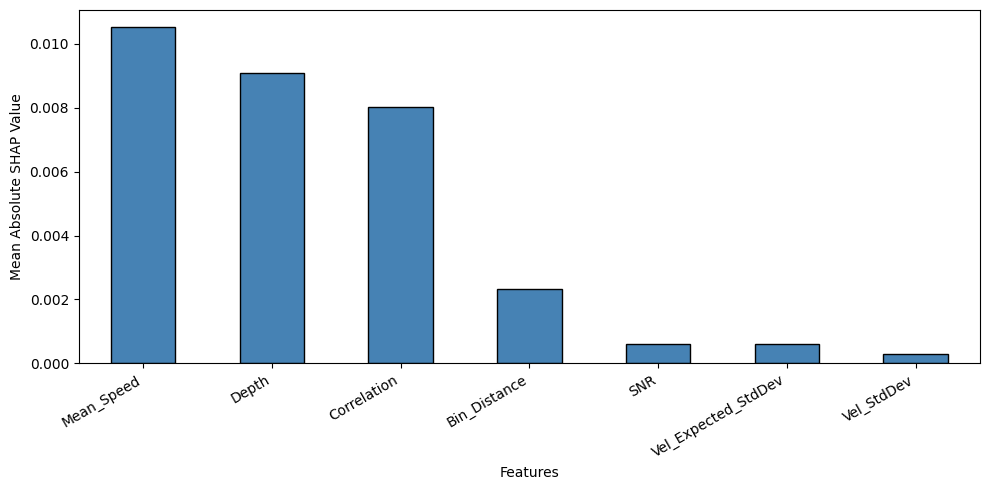

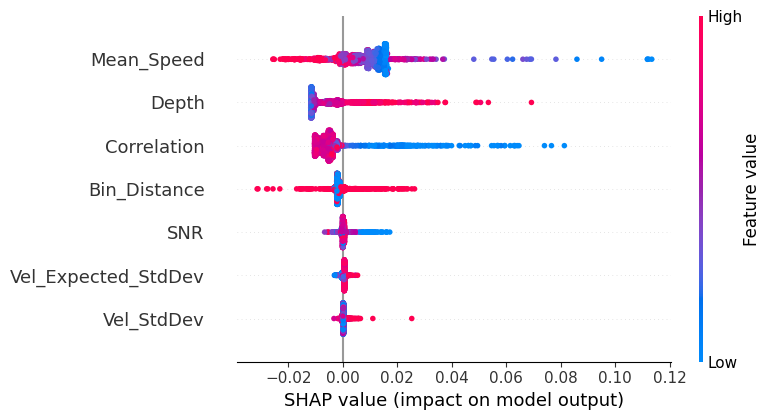


Mean |SHAP| per feature:
Mean_Speed             0.010537
Depth                  0.009096
Correlation            0.008022
Bin_Distance           0.002322
SNR                    0.000612
Vel_Expected_StdDev    0.000605
Vel_StdDev             0.000296


In [6]:
print('=== SHAP Analysis — RF on BT_Vel_stage1 (lab main target) ===')

rf_model, X_tr_s, X_te_s, y_tr, y_te = trained_s1['Random Forest']

explainer = shap.TreeExplainer(rf_model)
shap_vals = explainer.shap_values(X_te_s)

# Global SHAP bar chart
mean_shap = np.abs(shap_vals).mean(axis=0)
shap_df   = pd.Series(mean_shap, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(10,5))
shap_df.plot(kind='bar', color='steelblue', edgecolor='black')
#plt.title('SHAP Feature Importance — RF, Lab (BT_Vel_stage1)')
plt.ylabel('Mean Absolute SHAP Value')
plt.xlabel('Features')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('lab_shap_va_stage1.png', dpi=550)
plt.show()

# SHAP beeswarm
shap.summary_plot(shap_vals, X_te_s, feature_names=FEATURES, show=False)
#plt.title('SHAP Beeswarm — RF, Lab (BT_Vel_stage1)')
plt.tight_layout()
plt.savefig('lab_shap_beeswarm_va_stage1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMean |SHAP| per feature:')
print(shap_df.round(8).to_string())


---
### Enhanced Interpretability 
Permutation importance (all models), ALE, local SHAP, prediction intervals, and feature-set comparison. Main target: `BT_Vel_stage1`.

#### Permutation Importance (all models)

=== Permutation Importance (ALL models) ===
  Random Forest: top = Depth (ΔR²=4.4461)
  Gradient Boosting: top = Mean_Speed (ΔR²=2.3077)
  XGBoost: top = Mean_Speed (ΔR²=4.1873)
  LightGBM: top = Mean_Speed (ΔR²=2.6299)
  CatBoost: top = Mean_Speed (ΔR²=3.6785)
  OLS: top = Bin_Distance (ΔR²=1.0869)
  Ridge: top = Bin_Distance (ΔR²=1.0700)
  Lasso: top = Correlation (ΔR²=0.2732)

✅ Permutation importance (mean ΔR² when feature shuffled):
                     Random Forest  Gradient Boosting  XGBoost  LightGBM  CatBoost     OLS   Ridge   Lasso    MEAN
Mean_Speed                  3.8882             2.3077   4.1873    2.6299    3.6785  0.9728  0.9715  0.1733  2.3512
Depth                       4.4461             1.1202   3.0628    0.5389    1.1629  0.6187  0.6146  0.0384  1.4503
Correlation                 1.9675             1.6556   1.8381    2.3845    1.4593  0.0008  0.0013  0.2732  1.1975
Bin_Distance                0.2023             0.2357   0.4604    0.2102    0.4182  1.0869  1.0700

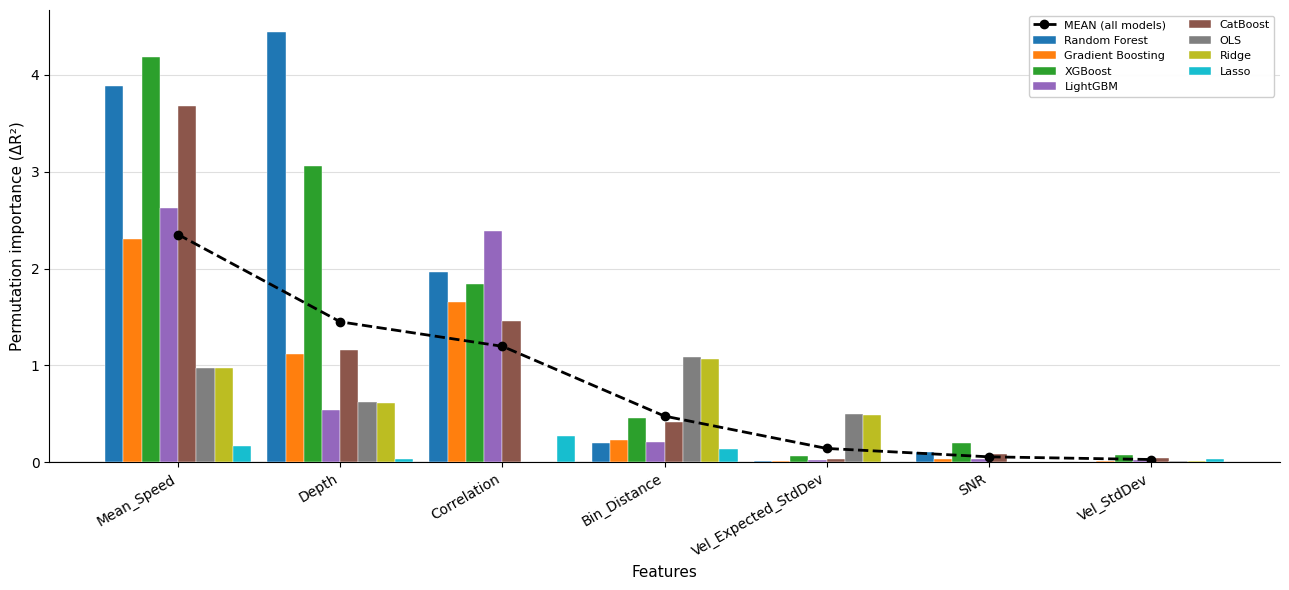

In [14]:
print('=== Permutation Importance (ALL models) ===')
# Model-agnostic. Cross-model agreement => feature relevance is a property of the
# task, not of any single model architecture .
from sklearn.inspection import permutation_importance

perm_results = {}
for name in ['Random Forest','Gradient Boosting','XGBoost','LightGBM','CatBoost',
             'OLS','Ridge','Lasso']:
    if name not in trained_s1:
        continue
    model, X_tr_s, X_te_s, y_tr, y_te = trained_s1[name]
    r = permutation_importance(model, X_te_s, y_te, n_repeats=20,
                               random_state=42, scoring='r2', n_jobs=-1)
    perm_results[name] = r.importances_mean
    print(f'  {name}: top = {FEATURES[r.importances_mean.argmax()]} '
          f'(ΔR²={r.importances_mean.max():.4f})')

perm_df = pd.DataFrame(perm_results, index=FEATURES)
perm_df['MEAN'] = perm_df.mean(axis=1)
perm_df = perm_df.sort_values('MEAN', ascending=False)

print('\n✅ Permutation importance (mean ΔR² when feature shuffled):')
print(perm_df.round(4).to_string())

# Grouped bar: each model + aggregate mean
fig, ax = plt.subplots(figsize=(13, 6))
plot_models = [c for c in perm_df.columns if c != 'MEAN']
x = np.arange(len(FEATURES)); w = 0.9 / len(plot_models)
cmap = plt.cm.tab10(np.linspace(0, 1, len(plot_models)))
order = perm_df.index.tolist()
for j, m in enumerate(plot_models):
    vals = [perm_df.loc[f, m] for f in order]
    ax.bar(x + j*w - 0.45 + w/2, vals, width=w, label=m, color=cmap[j],
           edgecolor='white', linewidth=0.3, zorder=3)
ax.plot(x, [perm_df.loc[f,'MEAN'] for f in order], 'k--o', lw=2,
        ms=6, label='MEAN (all models)', zorder=4)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Permutation importance (ΔR²)', fontsize=11)
ax.set_xlabel('Features', fontsize=11)
"""
ax.set_title('Permutation Importance across all ML models — Lab\n'
             'Cross-model agreement indicates task-level (not model-specific) feature relevance',
             fontsize=12, fontweight='bold')
"""
ax.axhline(0, color='black', lw=0.8); ax.legend(fontsize=8, ncol=2, framealpha=0.95)
ax.grid(axis='y', alpha=0.4, zorder=0); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('lab_permutation_importance.png', dpi=550, bbox_inches='tight', facecolor='white')
plt.show()


#### Accumulated Local Effects (ALE) — RF

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


=== Accumulated Local Effects (ALE) — RF ===


PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


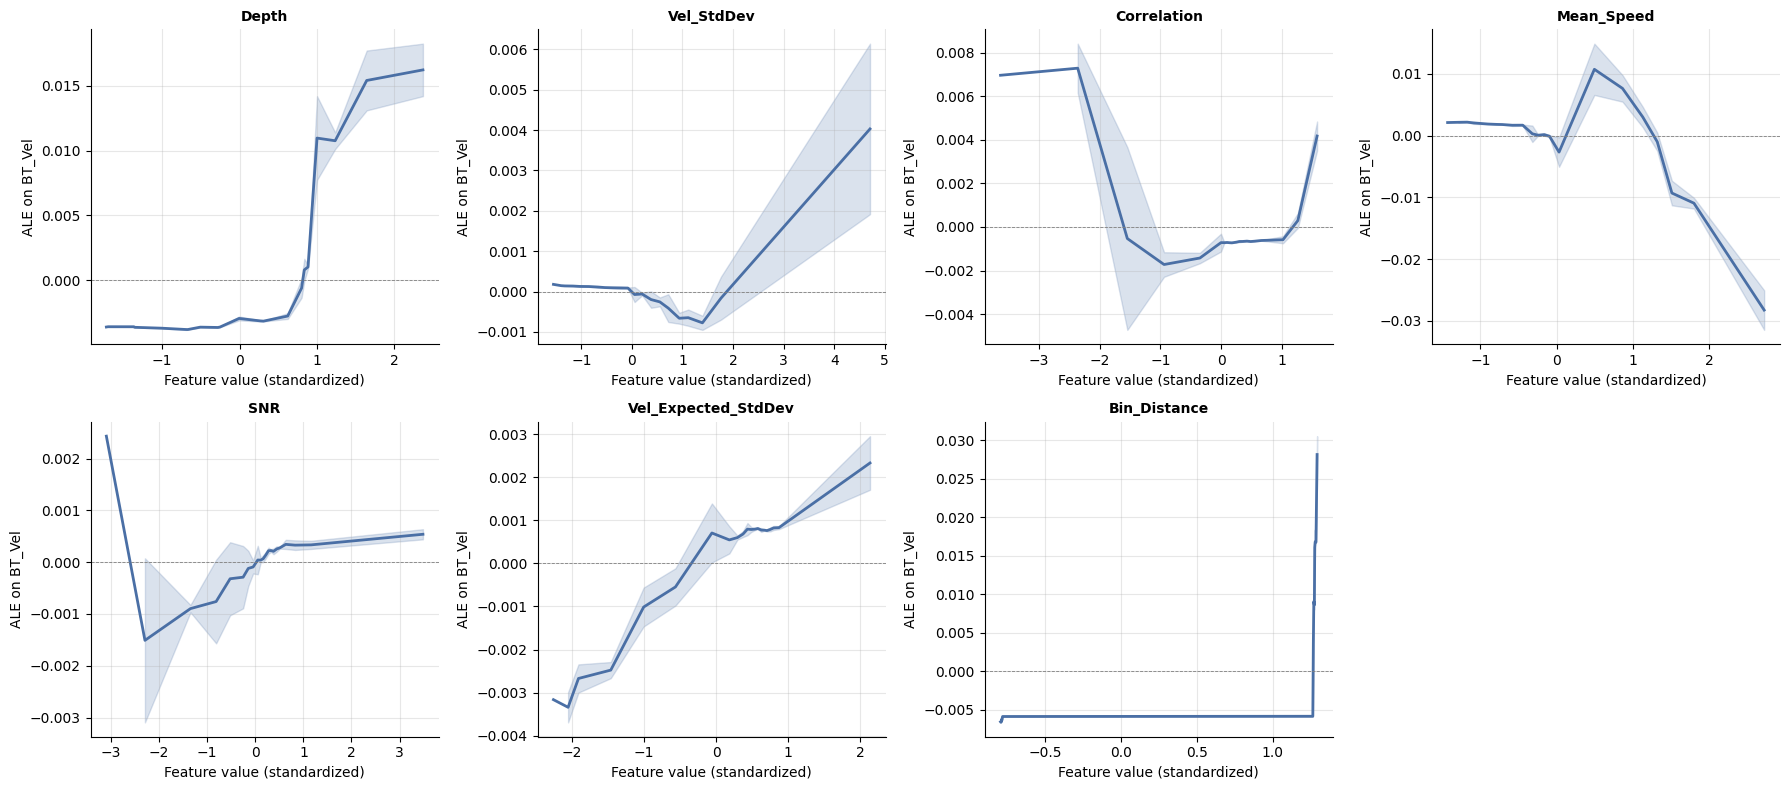

  ALE plots saved. Monotonic increasing ALE for Mean_Speed = physical (bedload up with flow).


In [10]:
print('=== Accumulated Local Effects (ALE) — RF ===')
# ALE shows the isolated marginal effect of each feature on the prediction,
# robust to feature correlation (unlike PDP). RF = best model.
try:
    from PyALE import ale
    HAS_PYALE = True
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable,'-m','pip','install','PyALE','-q','--break-system-packages'])
    try:
        from PyALE import ale; HAS_PYALE = True
    except Exception:
        HAS_PYALE = False
        print('  PyALE unavailable — using manual 1D ALE implementation')

rf_model, X_tr_s, X_te_s, y_tr, y_te = trained_s1['Random Forest']
X_te_df = pd.DataFrame(X_te_s, columns=FEATURES)

def manual_ale_1d(model, X, feat, bins=20):
    col = X[feat].values
    edges = np.quantile(col, np.linspace(0, 1, bins+1))
    edges = np.unique(edges)
    centers, eff = [], []
    for k in range(len(edges)-1):
        lo, hi = edges[k], edges[k+1]
        m = (col >= lo) & (col <= hi)
        if m.sum() < 2:
            continue
        Xl = X[m].copy(); Xu = X[m].copy()
        Xl[feat] = lo; Xu[feat] = hi
        delta = model.predict(Xu.values) - model.predict(Xl.values)
        centers.append((lo+hi)/2); eff.append(delta.mean())
    eff = np.cumsum(eff); eff = eff - eff.mean()   # centre
    return np.array(centers), eff

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for idx, feat in enumerate(FEATURES):
    ax = axes[idx]
    try:
        if HAS_PYALE:
            a = ale(X=X_te_df, model=rf_model, feature=[feat],
                    grid_size=20, include_CI=True, C=0.95, plot=False)
            xv = a.index.values; yv = a['eff'].values
            ax.plot(xv, yv, color='#4A6FA5', lw=2)
            if 'lowerCI_95%' in a.columns:
                ax.fill_between(xv, a['lowerCI_95%'], a['upperCI_95%'],
                                color='#4A6FA5', alpha=0.2)
        else:
            xv, yv = manual_ale_1d(rf_model, X_te_df, feat)
            ax.plot(xv, yv, color='#4A6FA5', lw=2)
    except Exception as e:
        xv, yv = manual_ale_1d(rf_model, X_te_df, feat)
        ax.plot(xv, yv, color='#4A6FA5', lw=2)
    ax.axhline(0, color='gray', lw=0.6, ls='--')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Feature value (standardized)', fontsize=10)
    ax.set_ylabel('ALE on BT_Vel', fontsize=10)
    ax.grid(alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for k in range(len(FEATURES), len(axes)):
    axes[k].axis('off')
#fig.suptitle('Accumulated Local Effects (ALE) — RF on BT_Vel_stage1 — Lab',
            # fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lab_ALE_plots.png', dpi=550, bbox_inches='tight', facecolor='white')
plt.show()
print('  ALE plots saved. Monotonic increasing ALE for Mean_Speed = physical (bedload up with flow).')


#### Local SHAP — individual predictions (RF)

===  Local SHAP (waterfall) — RF, high vs low BT_Vel_stage1 ===


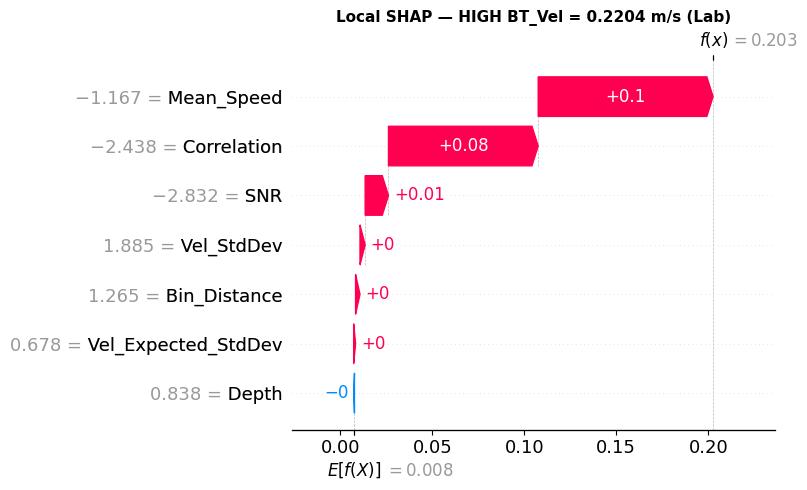


  HIGH prediction (true=0.2204, base=0.0077):
Mean_Speed             0.09503
Correlation            0.08135
SNR                    0.01267
Vel_StdDev             0.00280
Bin_Distance           0.00240
Vel_Expected_StdDev    0.00103
Depth                 -0.00042


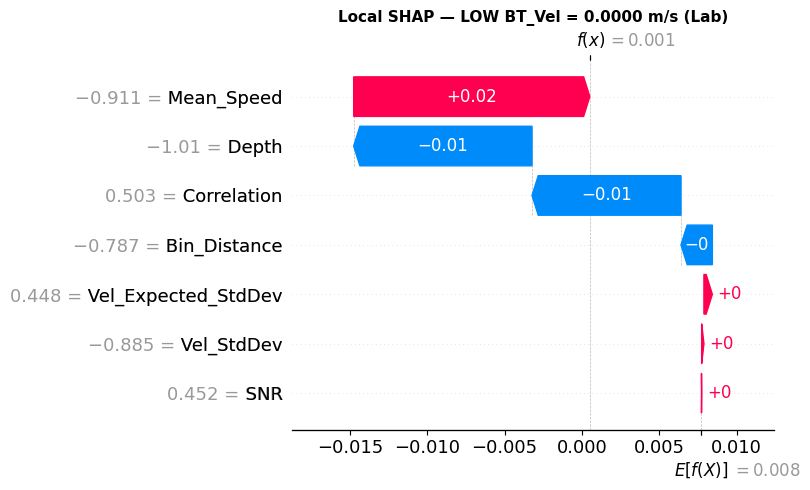


  LOW prediction (true=0.0000, base=0.0077):
Mean_Speed             0.01527
Depth                 -0.01153
Correlation           -0.00963
Bin_Distance          -0.00203
Vel_Expected_StdDev    0.00054
Vel_StdDev             0.00014
SNR                    0.00001


In [16]:
print('===  Local SHAP (waterfall) — RF, high vs low BT_Vel_stage1 ===')
# Explains two individual predictions: a high-transport and a low-transport ensemble.
import shap
rf_model, X_tr_s, X_te_s, y_tr, y_te = trained_s1['Random Forest']
explainer = shap.TreeExplainer(rf_model)

y_te_arr = np.asarray(y_te)
i_high = int(np.argmax(y_te_arr))   # strongest bed motion
i_low  = int(np.argmin(y_te_arr))   # near-stationary bed

sv_all = explainer.shap_values(X_te_s)
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = np.asarray(base_val).ravel()[0]

for label, i in [('HIGH', i_high), ('LOW', i_low)]:
    expl = shap.Explanation(values=sv_all[i], base_values=base_val,
                            data=X_te_s[i], feature_names=FEATURES)
    plt.figure()
    shap.plots.waterfall(expl, show=False, max_display=8)
    plt.title(f'Local SHAP — {label} BT_Vel = {y_te_arr[i]:.4f} m/s (Lab)',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'lab_local_shap_{label.lower()}.png', dpi=550,
                bbox_inches='tight', facecolor='white')
    plt.show()
    contrib = pd.Series(sv_all[i], index=FEATURES).sort_values(key=np.abs, ascending=False)
    print(f'\n  {label} prediction (true={y_te_arr[i]:.4f}, base={base_val:.4f}):')
    print(contrib.round(5).to_string())


#### Prediction Intervals — Quantile RF

=== Prediction Intervals — Split-Conformal Quantile RF ===
  Conformal adjustment qhat = 0.00032 (widens raw band)
  Raw quantile-RF:   coverage 72.8%  width 0.0110 m/s
  Conformalized:     coverage 90.0%  width 0.0116 m/s  (target 90%)


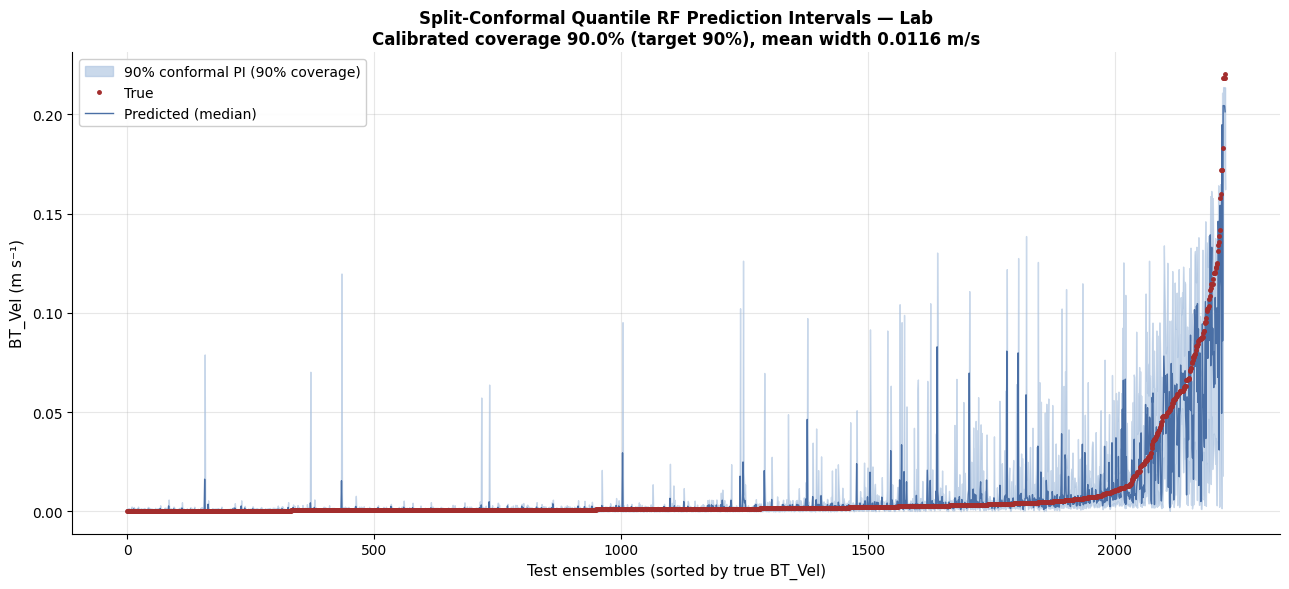

In [15]:
print('=== Prediction Intervals — Split-Conformal Quantile RF ===')
# Quantile RF gives raw 5th/95th percentiles, but these undercover because they
# capture only model spread. We calibrate with split-conformal adjustment on a
# held-out calibration set so empirical coverage matches the nominal 90%.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

rf_model, X_tr_s, X_te_s, y_tr, y_te = trained_s1['Random Forest']
y_tr_arr = np.asarray(y_tr); y_te_arr = np.asarray(y_te)

# Split training data into proper-train + calibration (for conformal)
X_pt, X_cal, y_pt, y_cal = train_test_split(
    X_tr_s, y_tr_arr, test_size=0.3, random_state=42)

qrf = RandomForestRegressor(n_estimators=300, random_state=42,
                            min_samples_leaf=5, n_jobs=-1).fit(X_pt, y_pt)

def pi_bounds(model, X, lo_q=5, hi_q=95):
    per_tree = np.stack([t.predict(X) for t in model.estimators_], axis=0)
    return (np.percentile(per_tree, lo_q, axis=0),
            np.percentile(per_tree, 50, axis=0),
            np.percentile(per_tree, hi_q, axis=0))

# Raw bounds on calibration set → compute conformity scores
lo_cal, med_cal, hi_cal = pi_bounds(qrf, X_cal)
# conformity score: how far outside the raw band each cal point lies (CQR)
scores = np.maximum(lo_cal - y_cal, y_cal - hi_cal)
# 90% coverage → take the ceil((n+1)*0.9)/n quantile of scores
n_cal = len(y_cal)
q_level = np.ceil((n_cal + 1) * 0.90) / n_cal
q_level = min(q_level, 1.0)
qhat = np.quantile(scores, q_level)
print(f'  Conformal adjustment qhat = {qhat:.5f} (widens raw band)')

# Apply to test set
lo_t, med_t, hi_t = pi_bounds(qrf, X_te_s)
lo_adj = lo_t - qhat
hi_adj = hi_t + qhat

cov_raw = ((y_te_arr >= lo_t)  & (y_te_arr <= hi_t)).mean()
cov_adj = ((y_te_arr >= lo_adj) & (y_te_arr <= hi_adj)).mean()
w_raw   = (hi_t   - lo_t).mean()
w_adj   = (hi_adj - lo_adj).mean()

print(f'  Raw quantile-RF:   coverage {cov_raw*100:.1f}%  width {w_raw:.4f} m/s')
print(f'  Conformalized:     coverage {cov_adj*100:.1f}%  width {w_adj:.4f} m/s  (target 90%)')

# Plot conformalized intervals sorted by true value
order = np.argsort(y_te_arr); xx = np.arange(len(order))
fig, ax = plt.subplots(figsize=(13, 6))
ax.fill_between(xx, lo_adj[order], hi_adj[order], color='#A8C0DE', alpha=0.6,
                label=f'90% conformal PI ({cov_adj*100:.0f}% coverage)', zorder=2)
ax.plot(xx, y_te_arr[order], 'o', color='#A32D2D', ms=2.5, label='True', zorder=4)
ax.plot(xx, med_t[order], '-', color='#4A6FA5', lw=1, label='Predicted (median)', zorder=3)
ax.set_xlabel('Test ensembles (sorted by true BT_Vel)', fontsize=11)
ax.set_ylabel('BT_Vel (m s⁻¹)', fontsize=11)
ax.set_title(f'Split-Conformal Quantile RF Prediction Intervals — Lab\n'
             f'Calibrated coverage {cov_adj*100:.1f}% (target 90%), mean width {w_adj:.4f} m/s',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.95)
ax.grid(alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('lab_prediction_intervals.png', dpi=550, bbox_inches='tight', facecolor='white')
plt.show()


#### Feature Set Comparison 

=== RC1.5: Feature Set Comparison — DISJOINT groups ===
  P: Physical only         (6 feats)  CV R² = 0.7711 ± 0.0178
  S: ADCP settings only    (4 feats)  CV R² = 0.6733 ± 0.0175
  P+S: Combined            (10 feats)  CV R² = 0.8567 ± 0.0201

✅ Feature set comparison (RF, BT_Vel_stage1):
          Feature Set  N features  CV R²    Std  N rows
     P: Physical only           6 0.7711 0.0178   11119
S: ADCP settings only           4 0.6733 0.0175   11119
        P+S: Combined          10 0.8567 0.0201   11119

INTERPRETATION:
  Physical-only R²   = 0.771  (hydraulic signal)
  Settings-only R²   = 0.673  (instrument/geometry signal)
  Combined R²        = 0.857
  Physical − Settings gap = +0.098  (>0 => hydraulics dominate, NOT instrument artefacts)


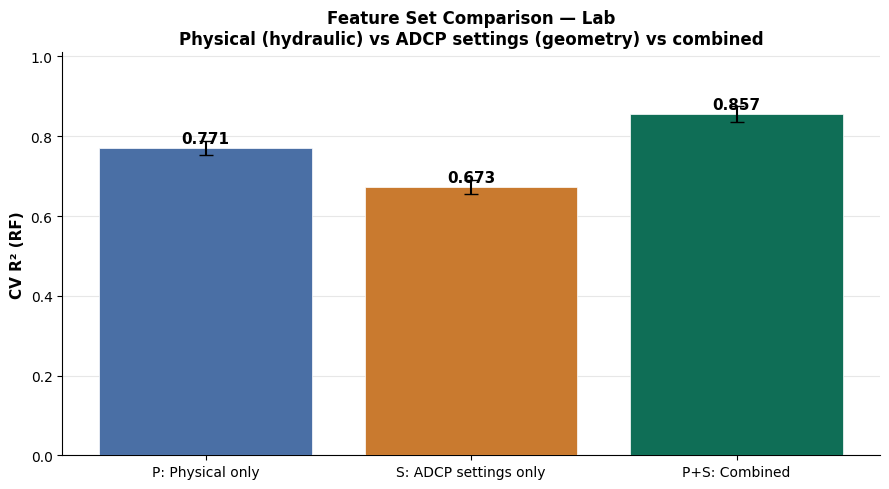

In [ ]:
print('=== Feature Set Comparison — DISJOINT groups ===')
# RC1 suggestion 5: contrast PHYSICAL/hydraulic features against ADCP
# SETTINGS/geometry features as SEPARATE groups (not nested), so the
# settings-only result is visible. Settings-alone giving low R² while
# physical-alone gives high R² => model learns hydraulics, not instrument

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.pipeline import make_pipeline

# Physical / hydraulic predictors
PHYSICAL = ['Mean_Speed','Depth','Vel_StdDev','Correlation','Vel_Expected_StdDev','SNR']
# ADCP settings / geometry predictors (bin size, blank distance, error velocity, range)
SETTINGS = [c for c in ['Bin_Distance','Cell_Size','Cell_Start','Error_Velocity']
            if c in df.columns]

feature_sets = {
    'P: Physical only':      PHYSICAL,
    'S: ADCP settings only': SETTINGS,
    'P+S: Combined':         PHYSICAL + SETTINGS,
}

def cv_r2_for(features, target_col):
    sub = df[features + [target_col]].dropna()
    Xf, yf = sub[features], sub[target_col]
    bins = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
    yb   = bins.fit_transform(yf.values.reshape(-1,1)).ravel().astype(int)
    skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pipe = make_pipeline(StandardScaler(),
                         RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    scores = cross_val_score(pipe, Xf, yf, cv=skf.split(Xf, yb), scoring='r2')
    return scores.mean(), scores.std(), len(sub)

fs_rows = []
for sname, feats in feature_sets.items():
    m, s, n = cv_r2_for(feats, 'BT_Vel_stage1')
    fs_rows.append({'Feature Set': sname, 'N features': len(feats),
                    'Features': ', '.join(feats),
                    'CV R²': round(m,4), 'Std': round(s,4), 'N rows': n})
    print(f'  {sname:24s} ({len(feats)} feats)  CV R² = {m:.4f} ± {s:.4f}')

fs_df = pd.DataFrame(fs_rows)
print('\n✅ Feature set comparison (RF, BT_Vel_stage1):')
print(fs_df[['Feature Set','N features','CV R²','Std','N rows']].to_string(index=False))

# Interpretation line
r_phys = fs_rows[0]['CV R²']; r_set = fs_rows[1]['CV R²']; r_comb = fs_rows[2]['CV R²']
print(f'\nINTERPRETATION:')
print(f'  Physical-only R²   = {r_phys:.3f}  (hydraulic signal)')
print(f'  Settings-only R²   = {r_set:.3f}  (instrument/geometry signal)')
print(f'  Combined R²        = {r_comb:.3f}')
print(f'  Physical − Settings gap = {r_phys - r_set:+.3f}  '
      f'(>0 => hydraulics dominate, NOT instrument artefacts)')

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
cols = ['#4A6FA5','#C97A2F','#0F6E56']   # physical=blue, settings=orange, combined=green
bars = ax.bar(fs_df['Feature Set'], fs_df['CV R²'], yerr=fs_df['Std'],
              color=cols, capsize=5, edgecolor='white', linewidth=0.5, zorder=3)
for b, v in zip(bars, fs_df['CV R²']):
    ax.text(b.get_x()+b.get_width()/2, v+0.012, f'{v:.3f}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('CV R² (RF)', fontsize=11, fontweight='bold')
ax.set_title('Feature Set Comparison — Lab\n'
             'Physical (hydraulic) vs ADCP settings (geometry) vs combined',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(fs_df['CV R²'])*1.18)
ax.grid(axis='y', alpha=0.3, zorder=0); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('lab_feature_sets_disjoint.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


---
### Feature Correlation Heatmap — BT_Vel_stage1


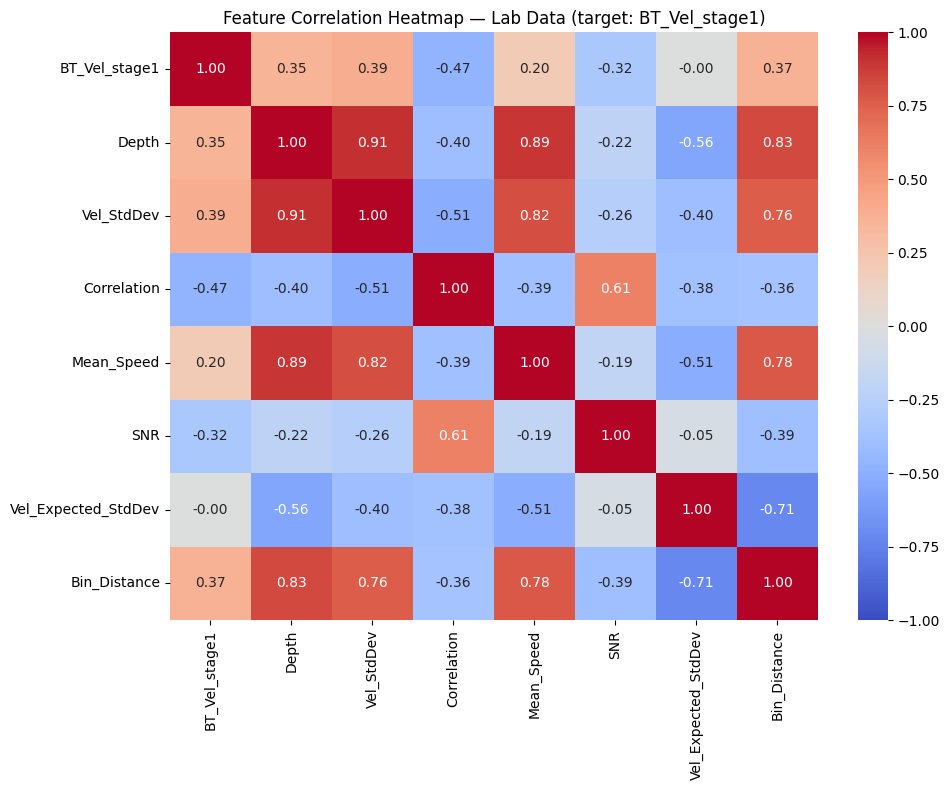


Correlation with BT_Vel_stage1:
BT_Vel_stage1          1.000
Vel_StdDev             0.395
Bin_Distance           0.373
Depth                  0.354
Mean_Speed             0.200
Vel_Expected_StdDev   -0.005
SNR                   -0.324
Correlation           -0.473
Name: BT_Vel_stage1, dtype: float64


In [11]:
heat_feats = ['BT_Vel_stage1'] + FEATURES
df_heat = df[heat_feats].dropna()

plt.figure(figsize=(10,8))
sns.heatmap(df_heat.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap — Lab Data (target: BT_Vel_stage1)')
plt.tight_layout()
plt.savefig('lab_correlation_va_stage1.png', dpi=150)
plt.show()

print('\nCorrelation with BT_Vel_stage1:')
print(df_heat.corr()['BT_Vel_stage1'].sort_values(ascending=False).round(3))
